# Comprehensive Similarity Analysis: Structure ↔ Spectra

**Goal:** Discover natural groupings in molecular data and assess cross-modal correspondence

**Pipeline:**
1. Efficient random sampling from large dataset
2. Structural fingerprinting (Morgan ECFP)
3. Spectral vectorization (NMR, IR, MS/MS)
4. Dimensionality reduction (UMAP, PCA)
5. Unsupervised clustering (HDBSCAN)
6. Cross-modal comparison
7. Visual & quantitative interpretation

## 1. Imports and Configuration

In [1]:
# Standard library
import glob
import json
import os
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Chemistry
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem import Draw

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage

import umap
import hdbscan

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✓ All imports successful")

✓ All imports successful


## 2. Configuration Parameters

In [2]:
# Sampling configuration
N_SAMPLE = 5000  # Number of molecules to sample (increased for better clustering)
N_PARQUET_FILES = 3  # None = all files, or specify number like 10

# Fingerprint configuration
FP_RADIUS = 2  # Morgan fingerprint radius (2 = ECFP4, 3 = ECFP6)
FP_NBITS = 2048  # Number of bits in fingerprint

# Spectral binning configuration
NMR_H_BINS = 200  # bins for 1H NMR (0-12 ppm)
NMR_C_BINS = 300  # bins for 13C NMR (0-220 ppm)
IR_BINS = 500  # bins for IR spectra
MSMS_BINS = 200  # bins for MS/MS (m/z)

# Clustering configuration
USE_HDBSCAN = False  # True for HDBSCAN, False for KMeans
N_CLUSTERS_KMEANS = 8  # Only used if USE_HDBSCAN = False
HDBSCAN_MIN_CLUSTER_SIZE = 10  # Reduced from 30 - adjust based on N_SAMPLE (rule of thumb: ~2-5% of sample size)

# Visualization subset sizes
N_VIS_HEATMAP = 300  # Number of molecules for similarity heatmap
N_VIS_STRUCTURES = 5  # Number of representative structures per cluster

# Paths
DATA_DIR = Path("../../data/raw/")
META_DIR = Path("../../data/meta_data/")

print(f"Configuration:")
print(f"  Sample size: {N_SAMPLE:,}")
print(f"  Fingerprint: ECFP{FP_RADIUS*2} ({FP_NBITS} bits)")
print(f"  Clustering: {'HDBSCAN' if USE_HDBSCAN else f'KMeans (k={N_CLUSTERS_KMEANS})'}")
if USE_HDBSCAN:
    print(f"  Min cluster size: {HDBSCAN_MIN_CLUSTER_SIZE} ({HDBSCAN_MIN_CLUSTER_SIZE/N_SAMPLE*100:.1f}% of sample)")

Configuration:
  Sample size: 5,000
  Fingerprint: ECFP4 (2048 bits)
  Clustering: KMeans (k=8)


## 3. Efficient Data Loading with Random Sampling

Strategy: Load parquet files and sample efficiently to avoid memory issues

In [3]:
import pyarrow.parquet as pq

def load_and_sample_data(data_dir, n_sample, n_parquet_files=None, random_seed=42):
    """
    Efficiently load and sample from parquet files using CHUNKED READING.
    Memory-safe for very large files.
    
    Strategy:
    1. Get list of all parquet files
    2. Read files in row group chunks
    3. Sample from each chunk
    4. Combine samples
    
    Args:
        data_dir: Directory containing parquet files
        n_sample: Target number of samples
        n_parquet_files: Number of parquet files to read (None = all)
        random_seed: Random seed for reproducibility
    
    Returns:
        DataFrame with sampled molecules
    """
    parquet_files = sorted(glob.glob(str(data_dir / "*.parquet")))
    
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found in {data_dir}")
    
    if n_parquet_files is not None:
        parquet_files = parquet_files[:n_parquet_files]
    
    print(f"Found {len(parquet_files)} parquet files to process")
    
    # Calculate samples per file
    samples_per_file = n_sample // len(parquet_files)
    remainder = n_sample % len(parquet_files)
    
    dfs = []
    total_rows = 0
    
    np.random.seed(random_seed)
    
    for i, file in enumerate(parquet_files):
        print(f"\nProcessing file {i+1}/{len(parquet_files)}: {Path(file).name}")
        
        # Open parquet file to read metadata
        parquet_file = pq.ParquetFile(file)
        num_rows = parquet_file.metadata.num_rows
        num_row_groups = parquet_file.num_row_groups
        total_rows += num_rows
        
        # Calculate how many samples from this file
        n_from_this_file = samples_per_file + (1 if i < remainder else 0)
        n_from_this_file = min(n_from_this_file, num_rows)
        
        print(f"  Total rows: {num_rows:,}, Row groups: {num_row_groups}")
        print(f"  Target samples: {n_from_this_file}")
        
        # Calculate sampling rate
        sample_rate = n_from_this_file / num_rows
        
        # Read and sample from each row group (chunk)
        file_samples = []
        rows_read = 0
        
        for rg_idx in range(num_row_groups):
            # Read one row group at a time
            row_group = parquet_file.read_row_group(rg_idx)
            df_chunk = row_group.to_pandas()
            rows_in_chunk = len(df_chunk)
            rows_read += rows_in_chunk
            
            # Sample from this chunk
            n_from_chunk = int(rows_in_chunk * sample_rate)
            if n_from_chunk > 0:
                df_chunk_sampled = df_chunk.sample(n=min(n_from_chunk, len(df_chunk)), 
                                                   random_state=random_seed + i + rg_idx)
                file_samples.append(df_chunk_sampled)
            
            # Clean up chunk
            del df_chunk
            del row_group
            
            # Progress update
            if (rg_idx + 1) % 10 == 0 or (rg_idx + 1) == num_row_groups:
                print(f"    Read {rg_idx + 1}/{num_row_groups} row groups ({rows_read:,} rows)")
        
        # Combine samples from all row groups of this file
        if file_samples:
            df_file_combined = pd.concat(file_samples, ignore_index=True)
            
            # If we got more than needed, downsample
            if len(df_file_combined) > n_from_this_file:
                df_file_combined = df_file_combined.sample(n=n_from_this_file, random_state=random_seed + i)
            
            dfs.append(df_file_combined)
            print(f"  ✓ Sampled {len(df_file_combined):,} rows from this file")
        
        # Clean up
        del parquet_file
    
    # Combine all samples
    print(f"\n{'='*60}")
    print(f"Combining samples from all files...")
    df_combined = pd.concat(dfs, ignore_index=True)
    
    # Shuffle the combined dataset
    df_combined = df_combined.sample(frac=1, random_state=random_seed).reset_index(drop=True)
    
    print(f"\nTotal dataset size: ~{total_rows:,} molecules")
    print(f"Final sample size: {len(df_combined):,} molecules")
    print(f"{'='*60}")
    
    return df_combined

# Load data
print("Starting memory-efficient data loading...\n")
df = load_and_sample_data(DATA_DIR, N_SAMPLE, N_PARQUET_FILES, RANDOM_SEED)

# Load metadata
meta_data_path = META_DIR / "meta_data_dict.json"
if meta_data_path.exists():
    with open(meta_data_path) as f:
        meta_data = json.load(f)
    print(f"\n✓ Metadata loaded: {list(meta_data.keys())}")
else:
    meta_data = {}
    print("\n⚠ No metadata file found, will infer dimensions from data")

print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Starting memory-efficient data loading...

Found 3 parquet files to process

Processing file 1/3: aligned_chunk_0.parquet
  Total rows: 3,235, Row groups: 1
  Target samples: 1667
    Read 1/1 row groups (3,235 rows)
  ✓ Sampled 1,667 rows from this file

Processing file 2/3: aligned_chunk_1.parquet
  Total rows: 3,273, Row groups: 1
  Target samples: 1667
    Read 1/1 row groups (3,273 rows)
  ✓ Sampled 1,666 rows from this file

Processing file 3/3: aligned_chunk_10.parquet
  Total rows: 3,244, Row groups: 1
  Target samples: 1666
    Read 1/1 row groups (3,244 rows)
  ✓ Sampled 1,666 rows from this file

Combining samples from all files...

Total dataset size: ~9,752 molecules
Final sample size: 4,999 molecules

✓ Metadata loaded: ['smiles', 'molecular_formula', 'h_nmr_spectra', 'c_nmr_spectra', 'h_nmr_peaks', 'c_nmr_peaks', 'hsqc_nmr_spectrum', 'hsqc_nmr_peaks', 'ir_spectra', 'msms_cfmid_positive_10ev', 'msms_cfmid_positive_20ev', 'msms_cfmid_positive_40ev', 'msms_cfmid_fragments_p

## 4. Data Validation and Cleaning

Remove invalid SMILES and optionally deduplicate

In [4]:
def validate_and_clean_data(df):
    """
    Validate SMILES and remove invalid entries.
    Optionally deduplicate by canonical SMILES.
    
    Args:
        df: DataFrame with 'smiles' column
    
    Returns:
        Cleaned DataFrame with 'mol' and 'canonical_smiles' columns added
    """
    print(f"Initial dataset: {len(df):,} molecules")
    
    # Parse SMILES and create RDKit mol objects
    df['mol'] = df['smiles'].apply(lambda x: Chem.MolFromSmiles(x) if pd.notna(x) else None)
    
    # Remove invalid SMILES
    n_invalid = df['mol'].isna().sum()
    df = df[df['mol'].notna()].copy()
    print(f"Removed {n_invalid:,} invalid SMILES")
    
    # Generate canonical SMILES
    df['canonical_smiles'] = df['mol'].apply(Chem.MolToSmiles)
    
    # Remove duplicates by canonical SMILES
    n_before = len(df)
    df = df.drop_duplicates(subset='canonical_smiles').reset_index(drop=True)
    n_duplicates = n_before - len(df)
    print(f"Removed {n_duplicates:,} duplicate structures")
    
    print(f"\nFinal clean dataset: {len(df):,} molecules")
    
    return df

df = validate_and_clean_data(df)
print(f"\n✓ Data validation complete")

Initial dataset: 4,999 molecules
Removed 0 invalid SMILES
Removed 0 duplicate structures

Final clean dataset: 4,999 molecules

✓ Data validation complete


## 5. Structural Representations

Compute Morgan fingerprints and molecular descriptors

In [5]:
def compute_morgan_fingerprints(mols, radius=2, nBits=2048):
    """
    Generate Morgan (ECFP) fingerprints.
    
    Args:
        mols: List of RDKit mol objects
        radius: Fingerprint radius (2=ECFP4, 3=ECFP6)
        nBits: Number of bits in fingerprint vector
    
    Returns:
        numpy array of shape (n_molecules, nBits)
    """
    fps = []
    for mol in mols:
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
            fps.append(np.array(fp))
        else:
            fps.append(np.zeros(nBits))
    return np.array(fps)

def compute_molecular_descriptors(mols):
    """
    Compute interpretable molecular descriptors.
    
    Descriptors:
    - MolWt: Molecular weight
    - LogP: Octanol-water partition coefficient
    - HBD: Hydrogen bond donors
    - HBA: Hydrogen bond acceptors
    - TPSA: Topological polar surface area
    - NumRotatableBonds: Rotatable bonds (flexibility)
    - NumAromaticRings: Aromatic rings
    - NumAliphaticRings: Aliphatic rings
    
    Args:
        mols: List of RDKit mol objects
    
    Returns:
        DataFrame with descriptor values
    """
    descriptors = []
    
    for mol in mols:
        if mol is not None:
            desc = {
                'MW': Descriptors.MolWt(mol),
                'LogP': Descriptors.MolLogP(mol),
                'HBD': Descriptors.NumHDonors(mol),
                'HBA': Descriptors.NumHAcceptors(mol),
                'TPSA': Descriptors.TPSA(mol),
                'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
                'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
                'NumAliphaticRings': rdMolDescriptors.CalcNumAliphaticRings(mol),
            }
        else:
            desc = {k: 0 for k in ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'NumRotatableBonds', 
                                    'NumAromaticRings', 'NumAliphaticRings']}
        descriptors.append(desc)
    
    return pd.DataFrame(descriptors)

# Compute fingerprints
print(f"Computing Morgan fingerprints (ECFP{FP_RADIUS*2}, {FP_NBITS} bits)...")
fps_morgan = compute_morgan_fingerprints(df['mol'].values, radius=FP_RADIUS, nBits=FP_NBITS)
print(f"  Shape: {fps_morgan.shape}")

# Compute descriptors
print(f"\nComputing molecular descriptors...")
df_descriptors = compute_molecular_descriptors(df['mol'].values)
print(f"  Descriptors: {list(df_descriptors.columns)}")
print(f"\n{df_descriptors.describe()}")

# Add descriptors to main dataframe
df = pd.concat([df, df_descriptors], axis=1)

print(f"\n✓ Structural representations computed")

Computing Morgan fingerprints (ECFP4, 2048 bits)...


[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerator
[20:03:35] DEPRECATION WARNING: please use MorganGenerat

  Shape: (4999, 2048)

Computing molecular descriptors...
  Descriptors: ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'NumRotatableBonds', 'NumAromaticRings', 'NumAliphaticRings']

                MW         LogP          HBD          HBA        TPSA  \
count  4999.000000  4999.000000  4999.000000  4999.000000  4999.00000   
mean    325.051425     3.172403     1.044009     4.085217    61.67133   
std      96.477627     1.605822     0.961475     1.852488    28.56086   
min      79.102000    -7.730400     0.000000     0.000000     0.00000   
25%     250.112000     2.127150     0.000000     3.000000    41.49000   
50%     321.424000     3.117200     1.000000     4.000000    59.50000   
75%     402.470500     4.195300     2.000000     5.000000    79.29000   
max     684.994000    11.056700    11.000000    16.000000   276.52000   

       NumRotatableBonds  NumAromaticRings  NumAliphaticRings  
count        4999.000000       4999.000000        4999.000000  
mean            4.198440          1.95659

## 6. Spectral Vectorization

Convert all spectral modalities to fixed-length vectors for comparison

In [6]:
def vectorize_nmr_spectra(spectra, n_bins=200, normalize_type='max'):
    """
    Convert NMR spectra to fixed-length vectors.
    Assumes spectra are already sampled at regular intervals.
    
    Args:
        spectra: List/array of NMR spectra
        n_bins: Target number of bins (for resampling)
        normalize_type: 'max', 'norm', or 'minmax'
    
    Returns:
        numpy array of shape (n_molecules, n_bins)
    """
    vectors = []
    
    for spec in spectra:
        if spec is None or len(spec) == 0:
            vectors.append(np.zeros(n_bins))
            continue
        
        # Resample to target bins
        spec_array = np.array(spec)
        if len(spec_array) != n_bins:
            # Simple linear interpolation
            x_old = np.linspace(0, 1, len(spec_array))
            x_new = np.linspace(0, 1, n_bins)
            spec_resampled = np.interp(x_new, x_old, spec_array)
        else:
            spec_resampled = spec_array
        
        # Normalize
        if normalize_type == 'max':
            max_val = np.max(np.abs(spec_resampled))
            if max_val > 0:
                spec_resampled = spec_resampled / max_val
        elif normalize_type == 'norm':
            norm = np.linalg.norm(spec_resampled)
            if norm > 0:
                spec_resampled = spec_resampled / norm
        elif normalize_type == 'minmax':
            min_val, max_val = np.min(spec_resampled), np.max(spec_resampled)
            if max_val > min_val:
                spec_resampled = (spec_resampled - min_val) / (max_val - min_val)
        
        vectors.append(spec_resampled)
    
    return np.array(vectors)

def vectorize_msms_spectra(df, energy_levels=['10ev', '20ev', '40ev'], 
                           polarity='positive', n_bins=200, max_mz=1000):
    """
    Convert MS/MS spectra (peak lists) to binned m/z intensity vectors.
    
    Args:
        df: DataFrame containing MS/MS columns
        energy_levels: List of energy levels to process
        polarity: 'positive' or 'negative'
        n_bins: Number of m/z bins
        max_mz: Maximum m/z value for binning
    
    Returns:
        numpy array of shape (n_molecules, n_bins * len(energy_levels))
    """
    all_vectors = []
    
    for energy in energy_levels:
        col_name = f"msms_{polarity}_{energy}"
        
        if col_name not in df.columns:
            print(f"Warning: Column {col_name} not found")
            continue
        
        vectors = []
        for peaks in df[col_name]:
            # Initialize empty spectrum
            binned_spectrum = np.zeros(n_bins)
            
            if peaks is not None and len(peaks) > 0:
                peaks_array = np.array(peaks)
                
                # peaks should be shape (n_peaks, 2) with [m/z, intensity]
                if len(peaks_array.shape) == 2 and peaks_array.shape[1] == 2:
                    mz_values = peaks_array[:, 0]
                    intensities = peaks_array[:, 1]
                    
                    # Bin the peaks
                    bin_edges = np.linspace(0, max_mz, n_bins + 1)
                    bin_indices = np.digitize(mz_values, bin_edges) - 1
                    
                    # Accumulate intensities in bins
                    for bin_idx, intensity in zip(bin_indices, intensities):
                        if 0 <= bin_idx < n_bins:
                            binned_spectrum[bin_idx] += intensity
                    
                    # Normalize
                    max_int = np.max(binned_spectrum)
                    if max_int > 0:
                        binned_spectrum = binned_spectrum / max_int
            
            vectors.append(binned_spectrum)
        
        all_vectors.append(np.array(vectors))
    
    # Concatenate all energy levels
    return np.hstack(all_vectors)

# Vectorize 1H NMR
print("Vectorizing 1H NMR spectra...")
if 'h_nmr_spectra' in df.columns:
    nmr_h_vectors = vectorize_nmr_spectra(df['h_nmr_spectra'].values, n_bins=NMR_H_BINS)
    print(f"  1H NMR shape: {nmr_h_vectors.shape}")
else:
    nmr_h_vectors = None
    print("  1H NMR not available")

# Vectorize 13C NMR
print("\nVectorizing 13C NMR spectra...")
if 'c_nmr_spectra' in df.columns:
    nmr_c_vectors = vectorize_nmr_spectra(df['c_nmr_spectra'].values, n_bins=NMR_C_BINS)
    print(f"  13C NMR shape: {nmr_c_vectors.shape}")
else:
    nmr_c_vectors = None
    print("  13C NMR not available")

# Vectorize IR
print("\nVectorizing IR spectra...")
if 'ir_spectra' in df.columns:
    ir_vectors = vectorize_nmr_spectra(df['ir_spectra'].values, n_bins=IR_BINS)
    print(f"  IR shape: {ir_vectors.shape}")
else:
    ir_vectors = None
    print("  IR not available")

# Vectorize MS/MS positive
print("\nVectorizing MS/MS positive mode...")
msms_pos_vectors = vectorize_msms_spectra(df, polarity='positive', n_bins=MSMS_BINS)
print(f"  MS/MS positive shape: {msms_pos_vectors.shape}")

# Vectorize MS/MS negative
print("\nVectorizing MS/MS negative mode...")
msms_neg_vectors = vectorize_msms_spectra(df, polarity='negative', n_bins=MSMS_BINS)
print(f"  MS/MS negative shape: {msms_neg_vectors.shape}")

print(f"\n✓ Spectral vectorization complete")

Vectorizing 1H NMR spectra...
  1H NMR shape: (4999, 200)

Vectorizing 13C NMR spectra...
  13C NMR shape: (4999, 300)

Vectorizing IR spectra...
  IR shape: (4999, 500)

Vectorizing MS/MS positive mode...
  MS/MS positive shape: (4999, 600)

Vectorizing MS/MS negative mode...
  MS/MS negative shape: (4999, 600)

✓ Spectral vectorization complete


## 7. Dimensionality Reduction

Apply UMAP and PCA to each modality for visualization and analysis

In [7]:
def apply_dimensionality_reduction(vectors, method='umap', n_components=2, 
                                   n_neighbors=15, min_dist=0.1, metric='euclidean'):
    """
    Apply dimensionality reduction.
    
    Args:
        vectors: Input feature matrix (n_samples, n_features)
        method: 'umap', 'pca', or 'both'
        n_components: Number of dimensions for output
        n_neighbors: UMAP parameter
        min_dist: UMAP parameter
        metric: Distance metric
    
    Returns:
        Dictionary with reduced embeddings
    """
    results = {}
    
    if method in ['pca', 'both']:
        print(f"  Applying PCA...")
        pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
        embedding_pca = pca.fit_transform(vectors)
        results['pca'] = embedding_pca
        results['pca_variance'] = pca.explained_variance_ratio_
        print(f"    Explained variance: {pca.explained_variance_ratio_.sum():.3f}")
    
    if method in ['umap', 'both']:
        print(f"  Applying UMAP...")
        reducer = umap.UMAP(
            n_components=n_components,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            random_state=RANDOM_SEED
        )
        embedding_umap = reducer.fit_transform(vectors)
        results['umap'] = embedding_umap
    
    return results

# Dictionary to store all embeddings
embeddings = {}

# Structure embeddings
print("\n1. Structure (Morgan fingerprints):")
embeddings['structure'] = apply_dimensionality_reduction(fps_morgan, method='both')

# NMR H embeddings
if nmr_h_vectors is not None:
    print("\n2. 1H NMR:")
    embeddings['nmr_h'] = apply_dimensionality_reduction(nmr_h_vectors, method='both')

# NMR C embeddings
if nmr_c_vectors is not None:
    print("\n3. 13C NMR:")
    embeddings['nmr_c'] = apply_dimensionality_reduction(nmr_c_vectors, method='both')

# IR embeddings
if ir_vectors is not None:
    print("\n4. IR:")
    embeddings['ir'] = apply_dimensionality_reduction(ir_vectors, method='both')

# MS/MS positive embeddings
print("\n5. MS/MS positive:")
embeddings['msms_pos'] = apply_dimensionality_reduction(msms_pos_vectors, method='both')

# MS/MS negative embeddings
print("\n6. MS/MS negative:")
embeddings['msms_neg'] = apply_dimensionality_reduction(msms_neg_vectors, method='both')

print(f"\n✓ Dimensionality reduction complete")
print(f"  Modalities processed: {list(embeddings.keys())}")


1. Structure (Morgan fingerprints):
  Applying PCA...
    Explained variance: 0.049
  Applying UMAP...

2. 1H NMR:
  Applying PCA...
    Explained variance: 0.067
  Applying UMAP...

3. 13C NMR:
  Applying PCA...
    Explained variance: 0.062
  Applying UMAP...

4. IR:
  Applying PCA...
    Explained variance: 0.130
  Applying UMAP...

5. MS/MS positive:
  Applying PCA...
    Explained variance: nan
  Applying UMAP...

6. MS/MS negative:
  Applying PCA...
    Explained variance: nan
  Applying UMAP...

✓ Dimensionality reduction complete
  Modalities processed: ['structure', 'nmr_h', 'nmr_c', 'ir', 'msms_pos', 'msms_neg']


## 8. Unsupervised Clustering

Discover natural groupings using HDBSCAN or KMeans

In [8]:
# Compatibility fix for HDBSCAN with newer scikit-learn
# This patch is idempotent - safe to run multiple times

import sklearn.utils.validation
import hdbscan.hdbscan_ as hdbscan_module

# Only apply patch if not already applied
if not hasattr(sklearn.utils.validation, '_hdbscan_patch_applied'):
    # Store the original function before any patching
    from sklearn.utils.validation import check_array as _true_original_check_array
    
    def _patched_check_array(*args, **kwargs):
        """Compatibility wrapper for check_array to handle parameter name change"""
        if 'force_all_finite' in kwargs:
            kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
        return _true_original_check_array(*args, **kwargs)
    
    # Apply the patch
    sklearn.utils.validation.check_array = _patched_check_array
    hdbscan_module.check_array = _patched_check_array
    
    # Mark as patched to prevent re-patching
    sklearn.utils.validation._hdbscan_patch_applied = True
    print("✓ HDBSCAN compatibility patch applied")
else:
    print("✓ HDBSCAN compatibility patch already applied (skipped)")

def cluster_data(vectors, method='hdbscan', n_clusters=8, min_cluster_size=30):
    """
    Perform clustering on feature vectors.
    
    Args:
        vectors: Feature matrix
        method: 'hdbscan' or 'kmeans'
        n_clusters: Number of clusters (KMeans only)
        min_cluster_size: Minimum cluster size (HDBSCAN only)
    
    Returns:
        Cluster labels and clustering object
    """
    if method == 'hdbscan':
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=10,
            metric='euclidean',
            cluster_selection_method='eom'
        )
        labels = clusterer.fit_predict(vectors)
        
        # HDBSCAN uses -1 for noise
        n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        
        print(f"    Clusters found: {n_clusters_found}")
        print(f"    Noise points: {n_noise} ({n_noise/len(labels)*100:.1f}%)")
        
    elif method == 'kmeans':
        clusterer = KMeans(
            n_clusters=n_clusters,
            random_state=RANDOM_SEED,
            n_init=10
        )
        labels = clusterer.fit_predict(vectors)
        print(f"    Clusters: {n_clusters}")
        print(f"    Inertia: {clusterer.inertia_:.2f}")
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Print cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    print(f"    Cluster sizes: {dict(zip(unique, counts))}")
    
    return labels, clusterer

# Dictionary to store cluster labels
cluster_labels = {}
clusterers = {}

method = 'hdbscan' if USE_HDBSCAN else 'kmeans'
print(f"\nClustering method: {method.upper()}\n")

# Cluster structures
print("1. Clustering structures (fingerprints):")
cluster_labels['structure'], clusterers['structure'] = cluster_data(
    fps_morgan, method=method, n_clusters=N_CLUSTERS_KMEANS, 
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE
)
df['cluster_struct'] = cluster_labels['structure']

# Cluster NMR H
if nmr_h_vectors is not None:
    print("\n2. Clustering 1H NMR:")
    cluster_labels['nmr_h'], clusterers['nmr_h'] = cluster_data(
        nmr_h_vectors, method=method, n_clusters=N_CLUSTERS_KMEANS,
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE
    )
    df['cluster_nmr_h'] = cluster_labels['nmr_h']

# Cluster NMR C
if nmr_c_vectors is not None:
    print("\n3. Clustering 13C NMR:")
    cluster_labels['nmr_c'], clusterers['nmr_c'] = cluster_data(
        nmr_c_vectors, method=method, n_clusters=N_CLUSTERS_KMEANS,
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE
    )
    df['cluster_nmr_c'] = cluster_labels['nmr_c']

# Cluster IR
if ir_vectors is not None:
    print("\n4. Clustering IR:")
    cluster_labels['ir'], clusterers['ir'] = cluster_data(
        ir_vectors, method=method, n_clusters=N_CLUSTERS_KMEANS,
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE
    )
    df['cluster_ir'] = cluster_labels['ir']

# Cluster MS/MS positive
print("\n5. Clustering MS/MS positive:")
cluster_labels['msms_pos'], clusterers['msms_pos'] = cluster_data(
    msms_pos_vectors, method=method, n_clusters=N_CLUSTERS_KMEANS,
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE
)
df['cluster_msms_pos'] = cluster_labels['msms_pos']

# Cluster MS/MS negative
print("\n6. Clustering MS/MS negative:")
cluster_labels['msms_neg'], clusterers['msms_neg'] = cluster_data(
    msms_neg_vectors, method=method, n_clusters=N_CLUSTERS_KMEANS,
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE
)
df['cluster_msms_neg'] = cluster_labels['msms_neg']

print(f"\n✓ Clustering complete")

✓ HDBSCAN compatibility patch applied

Clustering method: KMEANS

1. Clustering structures (fingerprints):
    Clusters: 8
    Inertia: 154140.53
    Cluster sizes: {np.int32(0): np.int64(411), np.int32(1): np.int64(531), np.int32(2): np.int64(366), np.int32(3): np.int64(868), np.int32(4): np.int64(383), np.int32(5): np.int64(1101), np.int32(6): np.int64(801), np.int32(7): np.int64(538)}

2. Clustering 1H NMR:
    Clusters: 8
    Inertia: 6872.88
    Cluster sizes: {np.int32(0): np.int64(606), np.int32(1): np.int64(304), np.int32(2): np.int64(2788), np.int32(3): np.int64(230), np.int32(4): np.int64(258), np.int32(5): np.int64(310), np.int32(6): np.int64(268), np.int32(7): np.int64(235)}

3. Clustering 13C NMR:
    Clusters: 8
    Inertia: 5823.22
    Cluster sizes: {np.int32(0): np.int64(3164), np.int32(1): np.int64(74), np.int32(2): np.int64(266), np.int32(3): np.int64(824), np.int32(4): np.int64(121), np.int32(5): np.int64(286), np.int32(6): np.int64(181), np.int32(7): np.int64(83)}


## 9. Visualization: Structure Embeddings

Visualize molecular structures in UMAP space

Creating structure UMAP plot...


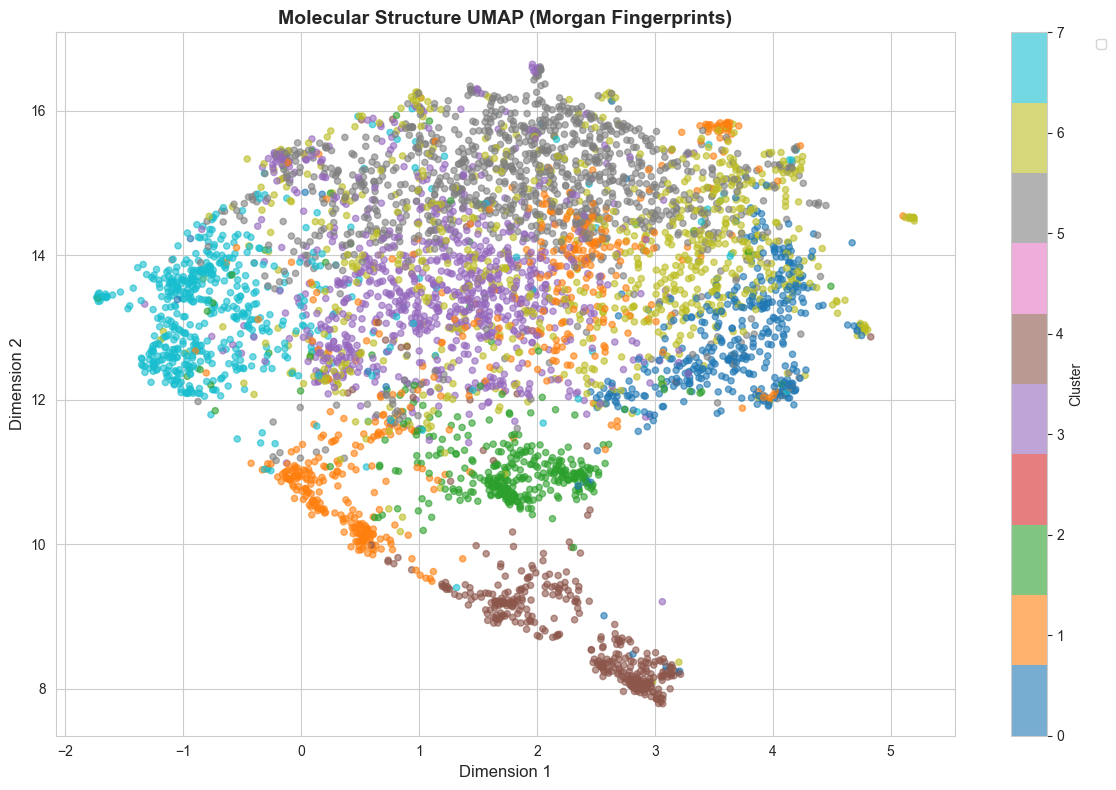

In [9]:
def plot_embedding_scatter(embedding, labels, title, figsize=(12, 8), 
                          cmap='tab10'):
    """
    Create scatter plot of 2D embedding colored by cluster labels.
    
    Args:
        embedding: 2D array of coordinates
        labels: Cluster labels
        title: Plot title
        figsize: Figure size
        cmap: Colormap name
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create color palette
    unique_labels = sorted(set(labels))
    n_clusters = len(unique_labels)
    
    if -1 in unique_labels:
        # HDBSCAN noise points
        colors = plt.cm.get_cmap(cmap)(np.linspace(0, 1, n_clusters))
        noise_mask = labels == -1
        
        # Plot noise points first (gray)
        ax.scatter(embedding[noise_mask, 0], embedding[noise_mask, 1],
                  c='lightgray', s=10, alpha=0.3, label='Noise')
        
        # Plot clustered points
        for i, label in enumerate([l for l in unique_labels if l != -1]):
            mask = labels == label
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                      c=[colors[i]], s=20, alpha=0.6, label=f'Cluster {label}')
    else:
        # KMeans or no noise
        scatter = ax.scatter(embedding[:, 0], embedding[:, 1],
                           c=labels, s=20, alpha=0.6, cmap=cmap)
        plt.colorbar(scatter, ax=ax, label='Cluster')
    
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=9)
    
    plt.tight_layout()
    
    plt.show()

# Plot structure UMAP
print("Creating structure UMAP plot...")
plot_embedding_scatter(
    embeddings['structure']['umap'],
    cluster_labels['structure'],
    'Molecular Structure UMAP (Morgan Fingerprints)'
)

## 10. Visualization: All Modalities UMAP Grid

Compare all spectral modalities side-by-side

Creating all modalities UMAP grid...


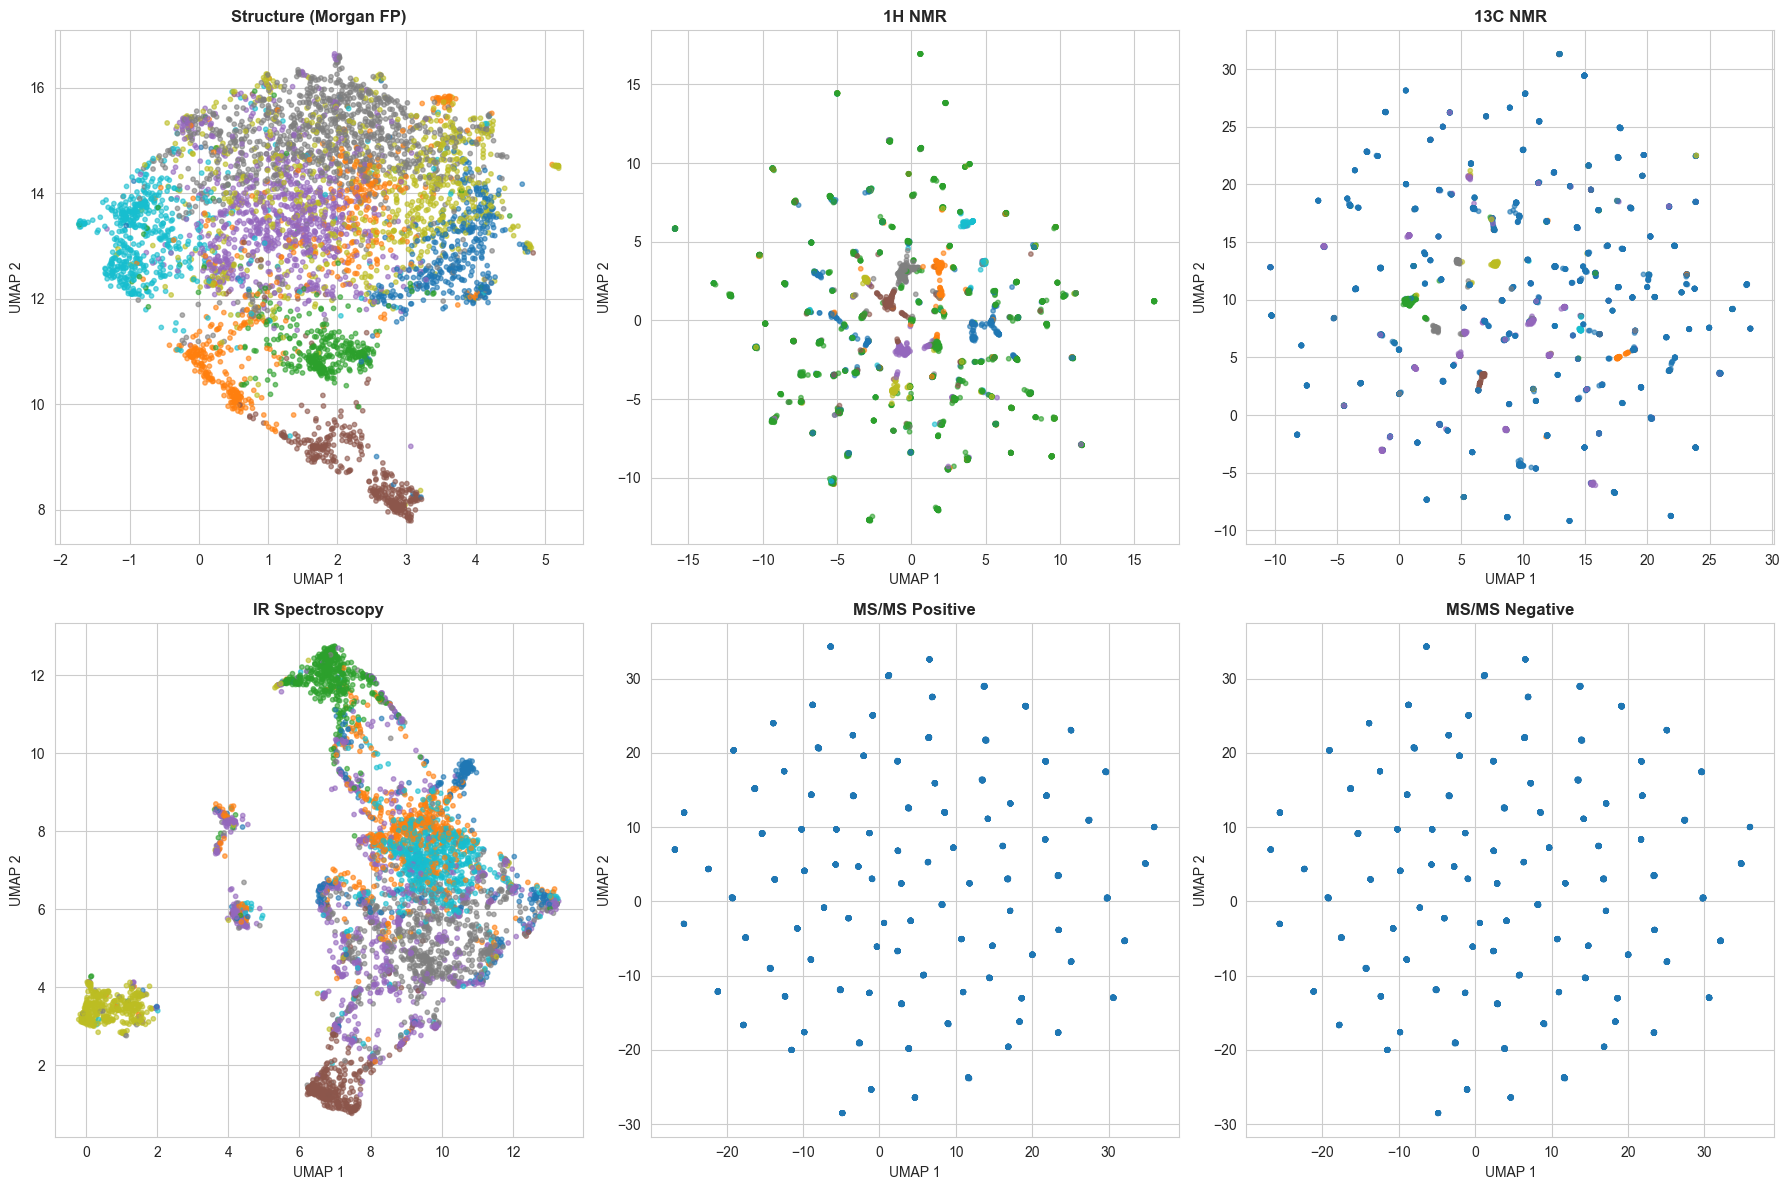

In [10]:
def plot_all_modalities_grid(embeddings, cluster_labels):
    """
    Create grid of UMAP plots for all modalities.
    """
    modalities = list(embeddings.keys())
    n_modalities = len(modalities)
    
    # Calculate grid dimensions
    n_cols = 3
    n_rows = int(np.ceil(n_modalities / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
    axes = axes.flatten() if n_modalities > 1 else [axes]
    
    titles = {
        'structure': 'Structure (Morgan FP)',
        'nmr_h': '1H NMR',
        'nmr_c': '13C NMR',
        'ir': 'IR Spectroscopy',
        'msms_pos': 'MS/MS Positive',
        'msms_neg': 'MS/MS Negative'
    }
    
    for i, modality in enumerate(modalities):
        ax = axes[i]
        
        if 'umap' in embeddings[modality]:
            embedding = embeddings[modality]['umap']
            labels = cluster_labels[modality]
            
            # Plot
            unique_labels = sorted(set(labels))
            
            if -1 in unique_labels:
                noise_mask = labels == -1
                ax.scatter(embedding[noise_mask, 0], embedding[noise_mask, 1],
                          c='lightgray', s=5, alpha=0.3)
                
                for label in [l for l in unique_labels if l != -1]:
                    mask = labels == label
                    ax.scatter(embedding[mask, 0], embedding[mask, 1],
                              s=10, alpha=0.6, label=f'{label}')
            else:
                scatter = ax.scatter(embedding[:, 0], embedding[:, 1],
                                   c=labels, s=10, alpha=0.6, cmap='tab10')
            
            ax.set_title(titles.get(modality, modality), fontsize=12, fontweight='bold')
            ax.set_xlabel('UMAP 1')
            ax.set_ylabel('UMAP 2')
    
    # Hide unused subplots
    for i in range(n_modalities, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Creating all modalities UMAP grid...")
plot_all_modalities_grid(
    embeddings,
    cluster_labels
)

## 11. Cross-Modal Agreement Analysis

Quantify how well different modalities agree on clustering

In [11]:
def compute_cluster_agreement(cluster_labels):
    """
    Compute pairwise cluster agreement using ARI and NMI.
    
    Args:
        cluster_labels: Dictionary of cluster label arrays
    
    Returns:
        DataFrames with ARI and NMI scores
    """
    modalities = list(cluster_labels.keys())
    n_mod = len(modalities)
    
    ari_matrix = np.zeros((n_mod, n_mod))
    nmi_matrix = np.zeros((n_mod, n_mod))
    
    for i, mod1 in enumerate(modalities):
        for j, mod2 in enumerate(modalities):
            labels1 = cluster_labels[mod1]
            labels2 = cluster_labels[mod2]
            
            # Remove noise points (-1) for fair comparison if using HDBSCAN
            valid_mask = (labels1 >= 0) & (labels2 >= 0)
            
            if valid_mask.sum() > 0:
                ari = adjusted_rand_score(labels1[valid_mask], labels2[valid_mask])
                nmi = normalized_mutual_info_score(labels1[valid_mask], labels2[valid_mask])
            else:
                ari = 0
                nmi = 0
            
            ari_matrix[i, j] = ari
            nmi_matrix[i, j] = nmi
    
    # Create readable labels
    labels_map = {
        'structure': 'Structure',
        'nmr_h': '1H NMR',
        'nmr_c': '13C NMR',
        'ir': 'IR',
        'msms_pos': 'MS/MS(+)',
        'msms_neg': 'MS/MS(-)'
    }
    readable_labels = [labels_map.get(m, m) for m in modalities]
    
    df_ari = pd.DataFrame(ari_matrix, index=readable_labels, columns=readable_labels)
    df_nmi = pd.DataFrame(nmi_matrix, index=readable_labels, columns=readable_labels)
    
    return df_ari, df_nmi

# Compute agreement
print("Computing cross-modal cluster agreement...")
df_ari, df_nmi = compute_cluster_agreement(cluster_labels)

print("\nAdjusted Rand Index (ARI):")
print(df_ari.round(3))

print("\nNormalized Mutual Information (NMI):")
print(df_nmi.round(3))

Computing cross-modal cluster agreement...

Adjusted Rand Index (ARI):
           Structure  1H NMR  13C NMR     IR  MS/MS(+)  MS/MS(-)
Structure      1.000   0.019    0.001  0.031       0.0       0.0
1H NMR         0.019   1.000    0.051  0.004       0.0       0.0
13C NMR        0.001   0.051    1.000  0.004       0.0       0.0
IR             0.031   0.004    0.004  1.000       0.0       0.0
MS/MS(+)       0.000   0.000    0.000  0.000       1.0       1.0
MS/MS(-)       0.000   0.000    0.000  0.000       1.0       1.0

Normalized Mutual Information (NMI):
           Structure  1H NMR  13C NMR     IR  MS/MS(+)  MS/MS(-)
Structure      1.000   0.060    0.043  0.064       0.0       0.0
1H NMR         0.060   1.000    0.021  0.022       0.0       0.0
13C NMR        0.043   0.021    1.000  0.012       0.0       0.0
IR             0.064   0.022    0.012  1.000       0.0       0.0
MS/MS(+)       0.000   0.000    0.000  0.000       1.0       1.0
MS/MS(-)       0.000   0.000    0.000  0.000  

## 12. Visualization: Cross-Modal Agreement Heatmaps

Creating cross-modal agreement heatmaps...


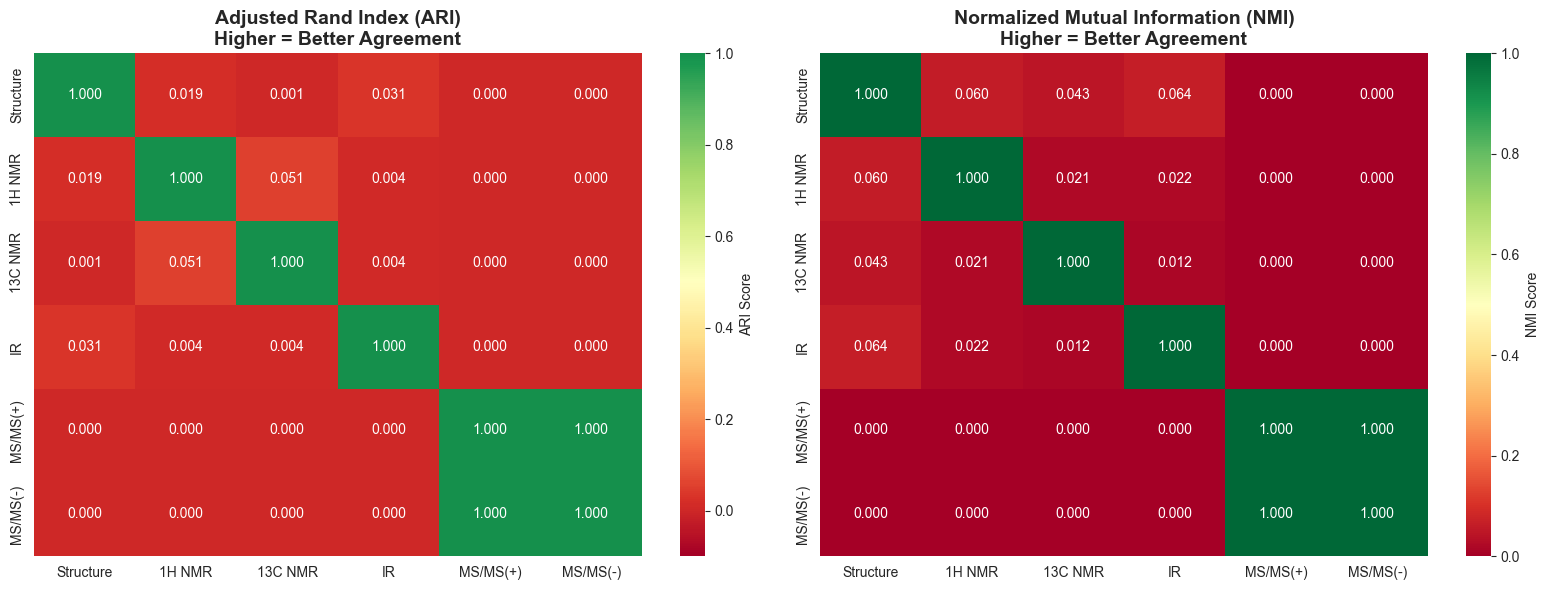

In [12]:
def plot_agreement_heatmaps(df_ari, df_nmi):
    """
    Plot heatmaps showing cross-modal cluster agreement.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # ARI heatmap
    sns.heatmap(df_ari, annot=True, fmt='.3f', cmap='RdYlGn', 
                vmin=-0.1, vmax=1.0, center=0.5, ax=axes[0],
                cbar_kws={'label': 'ARI Score'})
    axes[0].set_title('Adjusted Rand Index (ARI)\nHigher = Better Agreement', 
                      fontsize=14, fontweight='bold')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('')
    
    # NMI heatmap
    sns.heatmap(df_nmi, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1.0, center=0.5, ax=axes[1],
                cbar_kws={'label': 'NMI Score'})
    axes[1].set_title('Normalized Mutual Information (NMI)\nHigher = Better Agreement',
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()

print("Creating cross-modal agreement heatmaps...")
plot_agreement_heatmaps(df_ari, df_nmi)

## 13. Similarity Heatmaps

Visualize pairwise similarities for a subset of molecules

Creating structure similarity heatmap (300 molecules)...


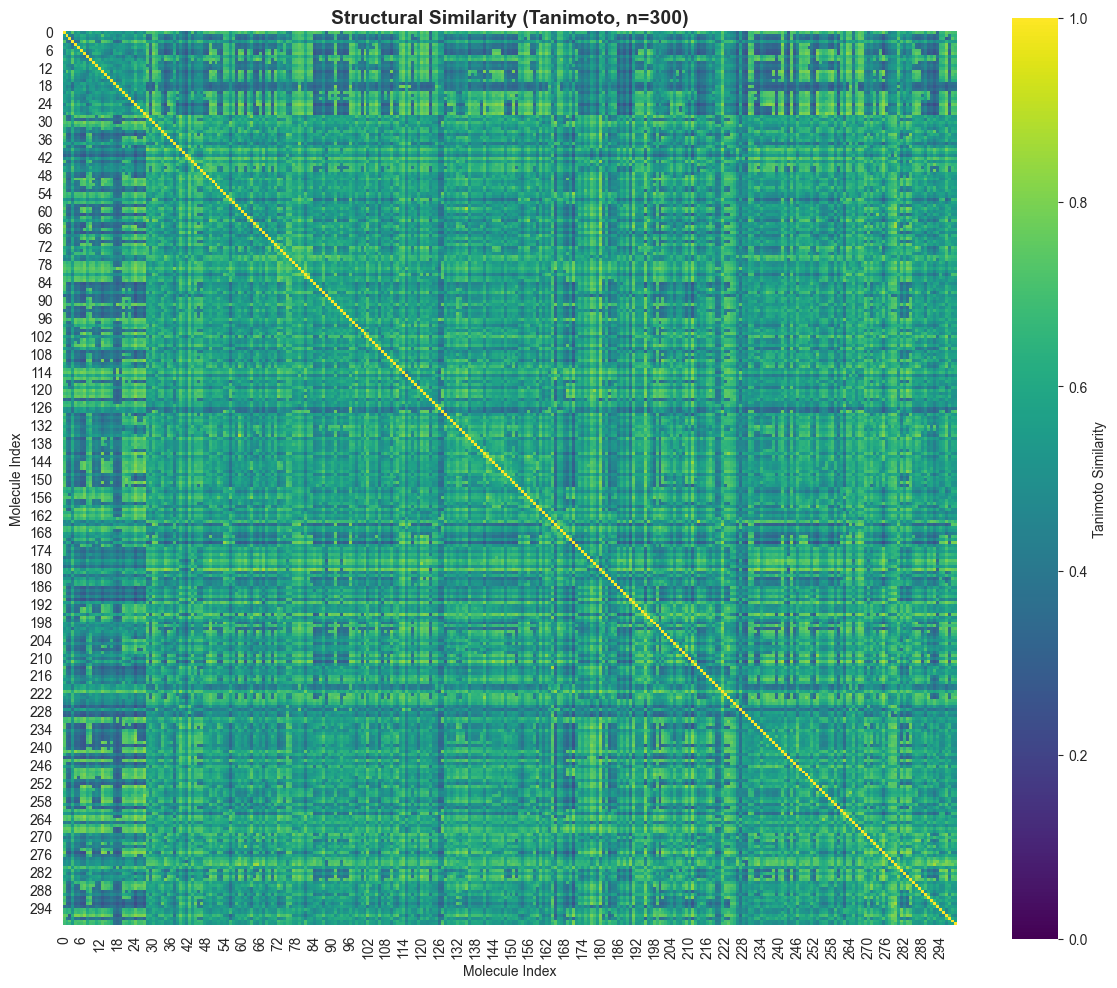


Creating IR similarity heatmap (300 molecules)...


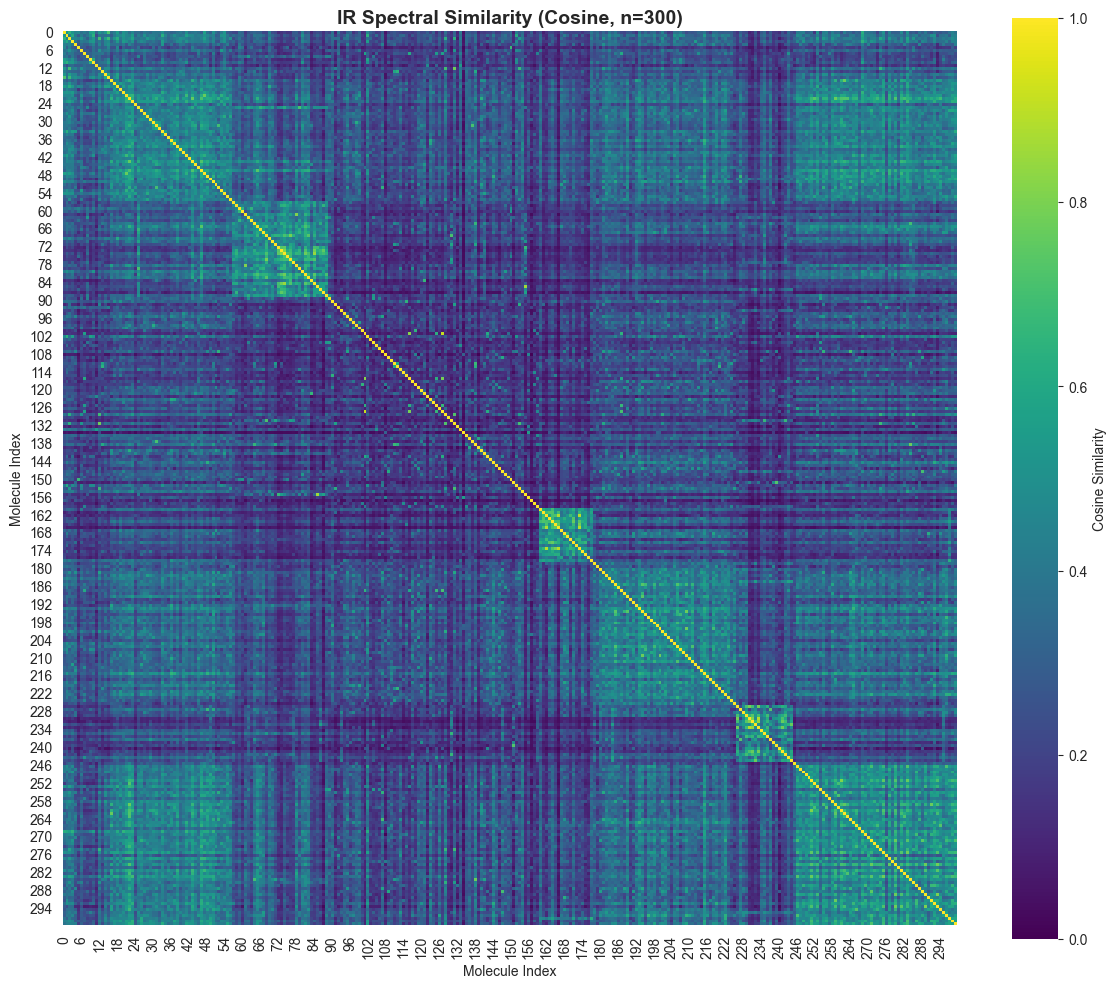

In [13]:
def compute_tanimoto_similarity(fps):
    """
    Compute Tanimoto similarity matrix for fingerprints.
    Tanimoto = (A ∩ B) / (A ∪ B)
    """
    n = len(fps)
    sim_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i, n):
            if i == j:
                sim_matrix[i, j] = 1.0
            else:
                intersection = np.sum(fps[i] & fps[i])
                union = np.sum(fps[i] | fps[j])
                tanimoto = intersection / union if union > 0 else 0
                sim_matrix[i, j] = tanimoto
                sim_matrix[j, i] = tanimoto
    
    return sim_matrix

def plot_similarity_heatmap(vectors, vector_type='cosine', n_samples=None,
                           cluster_labels=None, title=''):
    """
    Plot clustered similarity heatmap.
    
    Args:
        vectors: Feature vectors
        vector_type: 'cosine' for spectral, 'tanimoto' for fingerprints
        n_samples: Number of molecules to include
        cluster_labels: Cluster labels for ordering
        title: Plot title
    """
    # Sample subset
    if n_samples and n_samples < len(vectors):
        indices = np.random.choice(len(vectors), n_samples, replace=False)
        vectors_subset = vectors[indices]
        if cluster_labels is not None:
            cluster_labels_subset = cluster_labels[indices]
        else:
            cluster_labels_subset = None
    else:
        vectors_subset = vectors
        cluster_labels_subset = cluster_labels
    
    # Compute similarity
    if vector_type == 'tanimoto':
        sim_matrix = compute_tanimoto_similarity(vectors_subset.astype(bool))
    else:  # cosine
        sim_matrix = cosine_similarity(vectors_subset)
    
    # Sort by cluster labels if provided
    if cluster_labels_subset is not None:
        sort_indices = np.argsort(cluster_labels_subset)
        sim_matrix = sim_matrix[sort_indices][:, sort_indices]
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    sns.heatmap(sim_matrix, cmap='viridis', vmin=0, vmax=1,
                cbar_kws={'label': f'{vector_type.capitalize()} Similarity'},
                ax=ax, square=True)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Molecule Index')
    ax.set_ylabel('Molecule Index')
    
    plt.tight_layout()
    
    plt.show()

# Structure similarity (Tanimoto)
print(f"Creating structure similarity heatmap ({N_VIS_HEATMAP} molecules)...")
plot_similarity_heatmap(
    fps_morgan,
    vector_type='tanimoto',
    n_samples=N_VIS_HEATMAP,
    cluster_labels=cluster_labels['structure'],
    title=f'Structural Similarity (Tanimoto, n={N_VIS_HEATMAP})'
)

# IR similarity (Cosine)
if ir_vectors is not None:
    print(f"\nCreating IR similarity heatmap ({N_VIS_HEATMAP} molecules)...")
    plot_similarity_heatmap(
        ir_vectors,
        vector_type='cosine',
        n_samples=N_VIS_HEATMAP,
        cluster_labels=cluster_labels['ir'],
        title=f'IR Spectral Similarity (Cosine, n={N_VIS_HEATMAP})'
    )

## 14. Cluster Spectral Fingerprints

Show average spectra for each cluster to identify characteristic features

Creating IR cluster average spectra...


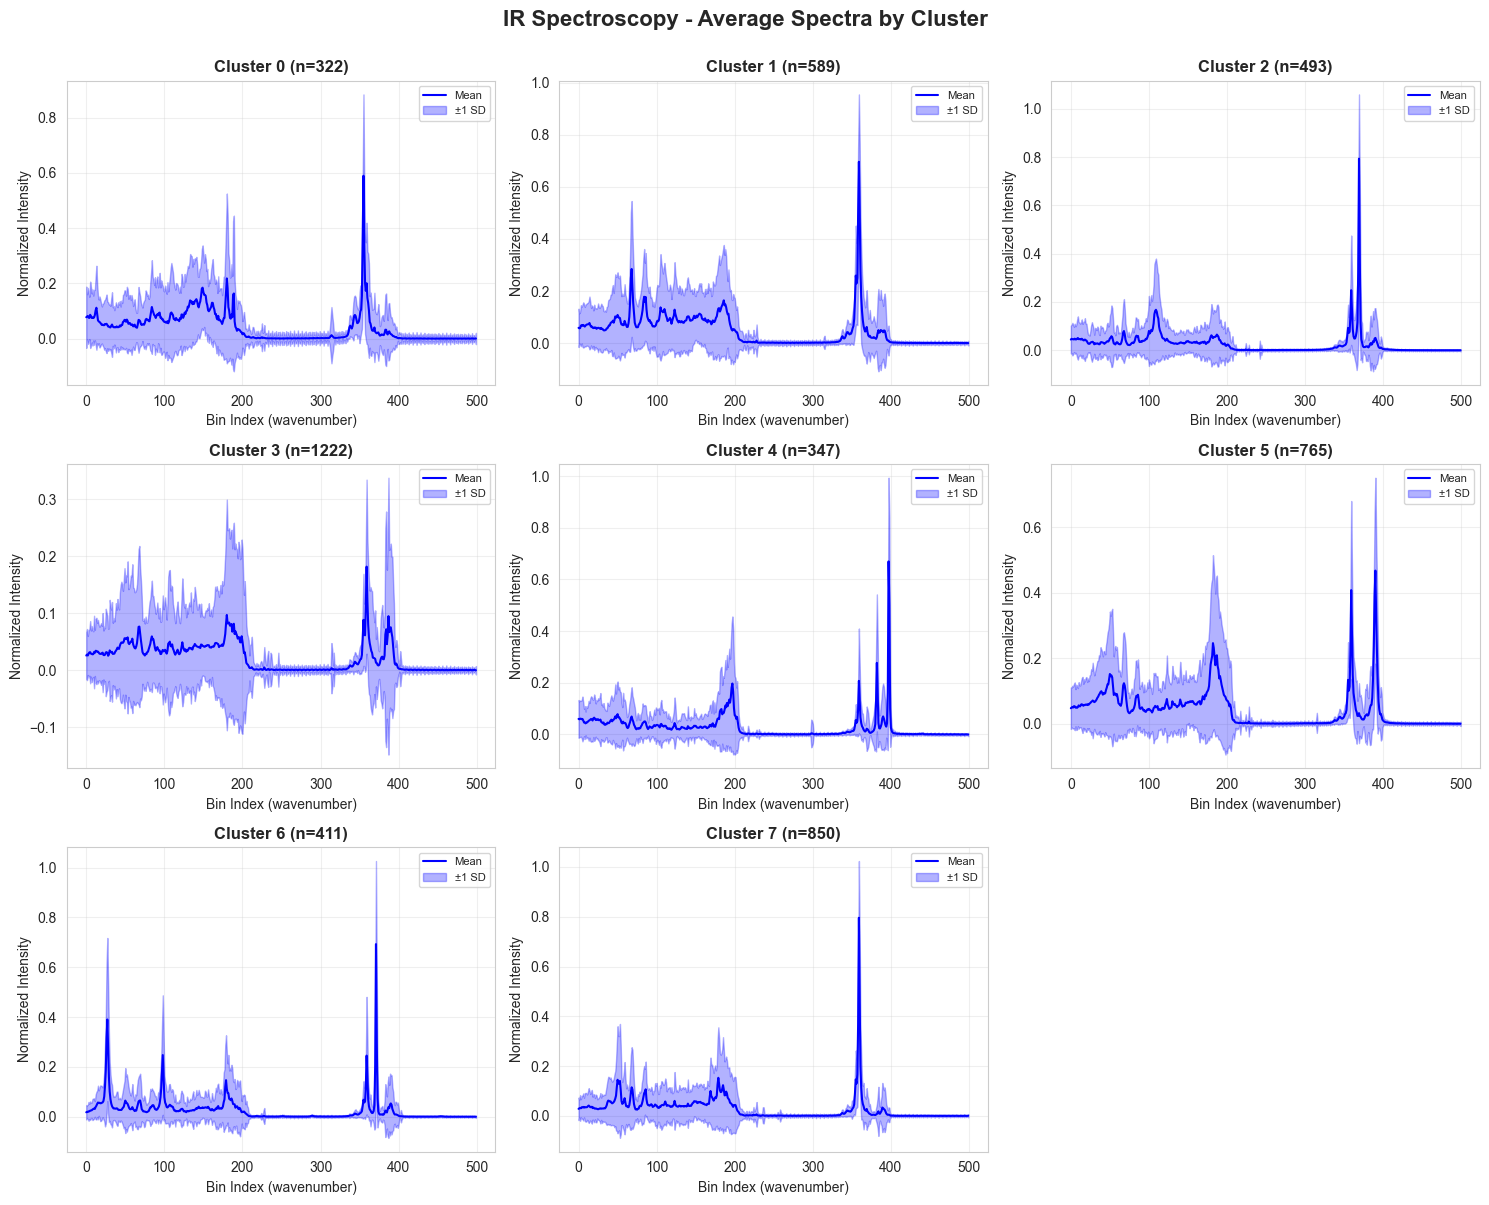


Creating MS/MS positive cluster average spectra...


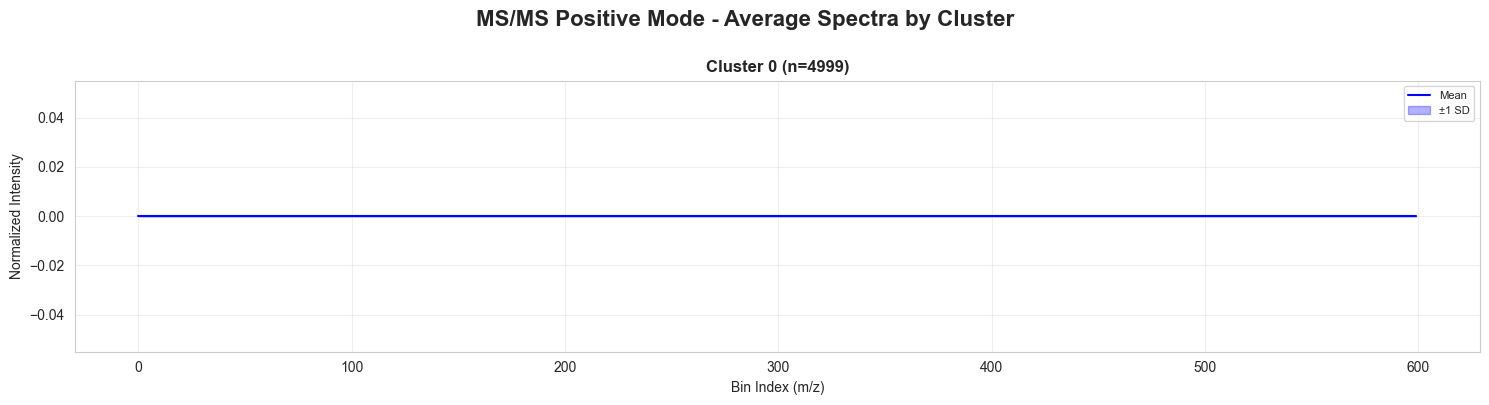

In [14]:
def plot_cluster_average_spectra(vectors, cluster_labels, modality_name,
                                 x_label='', y_label='Intensity',
                                 x_values=None):
    """
    Plot average spectrum for each cluster with variance bands.
    
    Args:
        vectors: Spectral vectors
        cluster_labels: Cluster assignments
        modality_name: Name of modality for title
        x_label: X-axis label
        y_label: Y-axis label
        x_values: X-axis values (optional)
    """
    unique_clusters = sorted([c for c in set(cluster_labels) if c >= 0])
    n_clusters = len(unique_clusters)
    
    if n_clusters == 0:
        print(f"  No valid clusters for {modality_name}")
        return
    
    # Calculate grid dimensions
    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    if n_clusters == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    if x_values is None:
        x_values = np.arange(vectors.shape[1])
    
    for i, cluster in enumerate(unique_clusters):
        ax = axes[i]
        
        # Get spectra for this cluster
        cluster_mask = cluster_labels == cluster
        cluster_spectra = vectors[cluster_mask]
        
        if len(cluster_spectra) == 0:
            continue
        
        # Compute mean and std
        mean_spectrum = np.mean(cluster_spectra, axis=0)
        std_spectrum = np.std(cluster_spectra, axis=0)
        
        # Plot mean
        ax.plot(x_values, mean_spectrum, 'b-', linewidth=1.5, label='Mean')
        
        # Plot variance band
        ax.fill_between(x_values, 
                        mean_spectrum - std_spectrum,
                        mean_spectrum + std_spectrum,
                        alpha=0.3, color='blue', label='±1 SD')
        
        ax.set_title(f'Cluster {cluster} (n={cluster_mask.sum()})', fontweight='bold')
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_clusters, len(axes)):
        axes[i].axis('off')
    
    fig.suptitle(f'{modality_name} - Average Spectra by Cluster', 
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    plt.show()

# IR cluster spectra
if ir_vectors is not None:
    print("Creating IR cluster average spectra...")
    plot_cluster_average_spectra(
        ir_vectors,
        cluster_labels['ir'],
        'IR Spectroscopy',
        x_label='Bin Index (wavenumber)',
        y_label='Normalized Intensity'
    )

# MS/MS positive cluster spectra
print("\nCreating MS/MS positive cluster average spectra...")
plot_cluster_average_spectra(
    msms_pos_vectors,
    cluster_labels['msms_pos'],
    'MS/MS Positive Mode',
    x_label='Bin Index (m/z)',
    y_label='Normalized Intensity'
)

## 15. Representative Structures per Cluster

Visualize example molecules from each structural cluster

Visualizing representative structures...
Drawing representatives for 8 clusters...


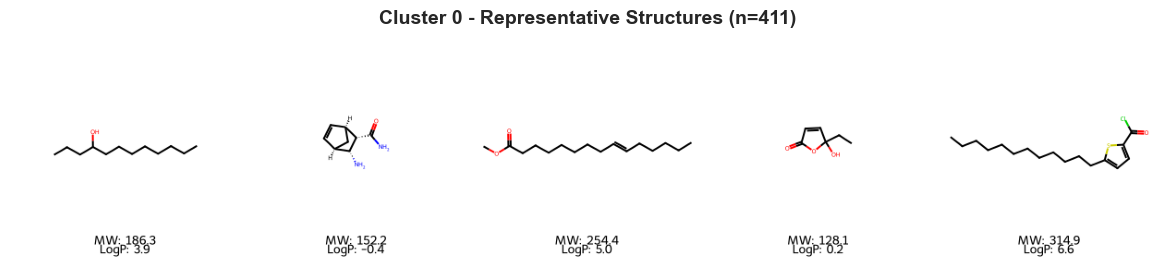

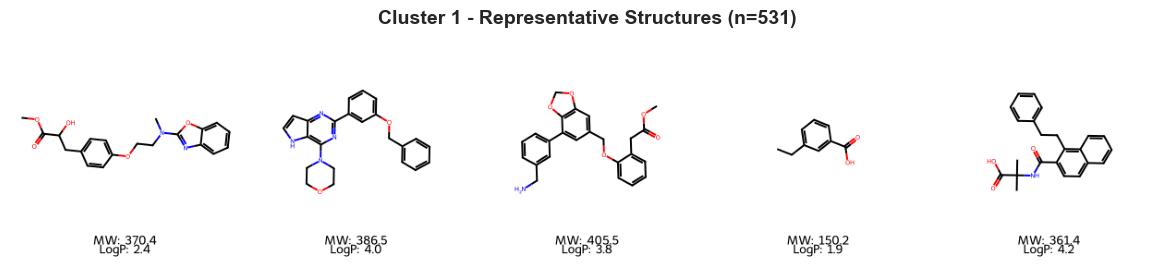

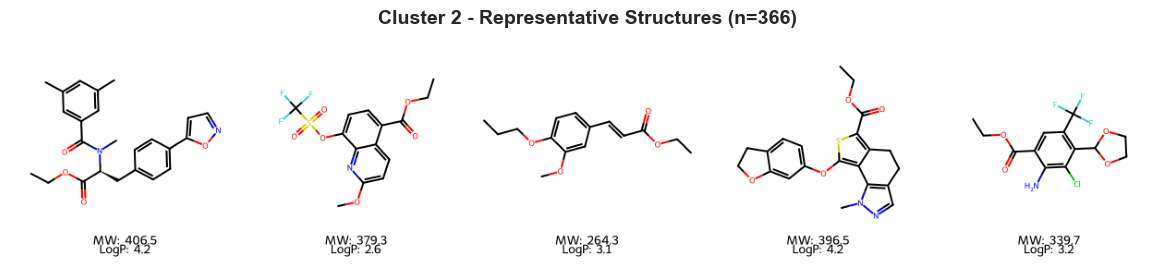

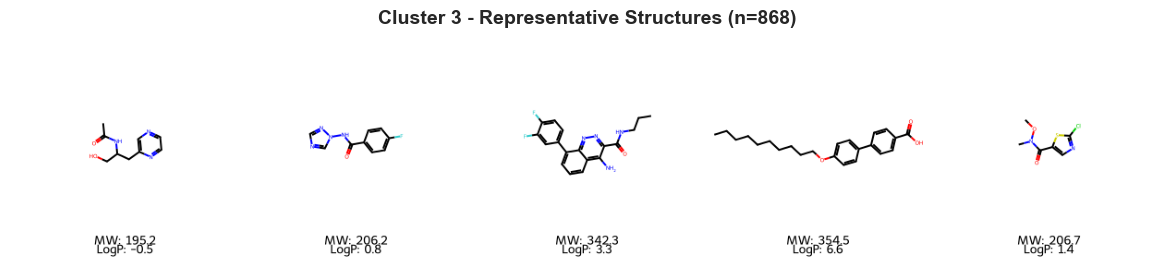

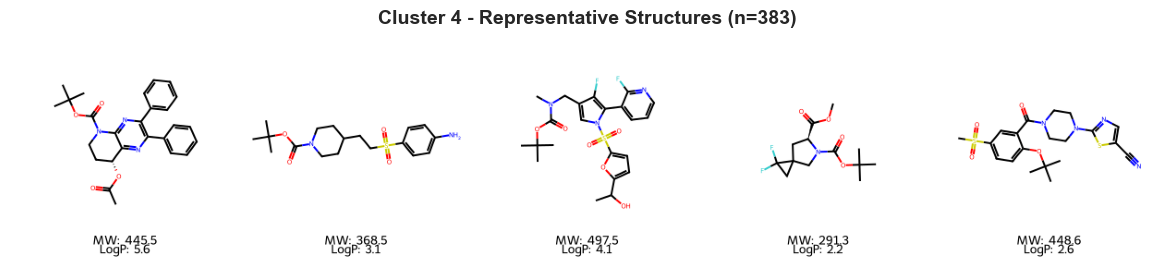

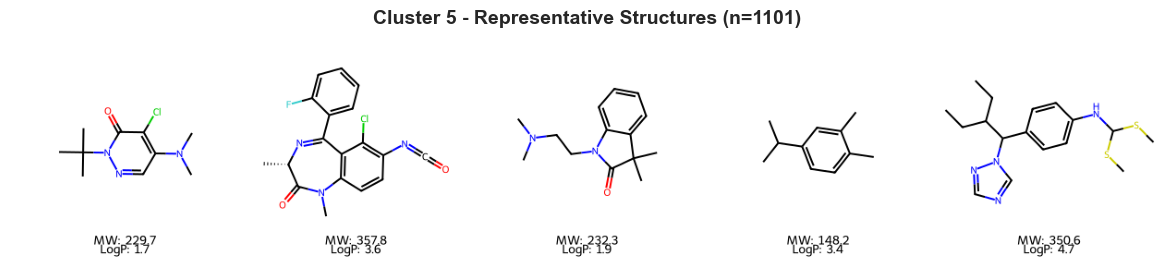

In [15]:
def visualize_cluster_representatives(df, cluster_col='cluster_struct', 
                                      n_per_cluster=5):
    """
    Draw representative molecules from each cluster.
    
    Args:
        df: DataFrame with 'mol' and cluster column
        cluster_col: Name of cluster label column
        n_per_cluster: Number of representatives per cluster
    """
    unique_clusters = sorted([c for c in df[cluster_col].unique() if c >= 0])
    
    print(f"Drawing representatives for {len(unique_clusters)} clusters...")
    
    for cluster in unique_clusters[:6]:  # Limit to first 6 clusters for display
        cluster_df = df[df[cluster_col] == cluster]
        
        if len(cluster_df) == 0:
            continue
        
        # Sample representatives
        n_sample = min(n_per_cluster, len(cluster_df))
        sample_df = cluster_df.sample(n=n_sample, random_state=RANDOM_SEED)
        
        mols = sample_df['mol'].tolist()
        legends = [f"MW: {mw:.1f}\nLogP: {logp:.1f}" 
                  for mw, logp in zip(sample_df['MW'], sample_df['LogP'])]
        
        img = Draw.MolsToGridImage(
            mols, 
            molsPerRow=n_sample,
            subImgSize=(250, 250),
            legends=legends,
            returnPNG=False
        )
        
        plt.figure(figsize=(15, 3))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Cluster {cluster} - Representative Structures (n={len(cluster_df)})',
                 fontsize=14, fontweight='bold', pad=10)
        
        plt.show()

print("Visualizing representative structures...")
visualize_cluster_representatives(
    df,
    cluster_col='cluster_struct',
    n_per_cluster=N_VIS_STRUCTURES
)

## 16. Descriptor Analysis by Cluster

Understand chemical properties that distinguish clusters

Creating descriptor distribution plots...


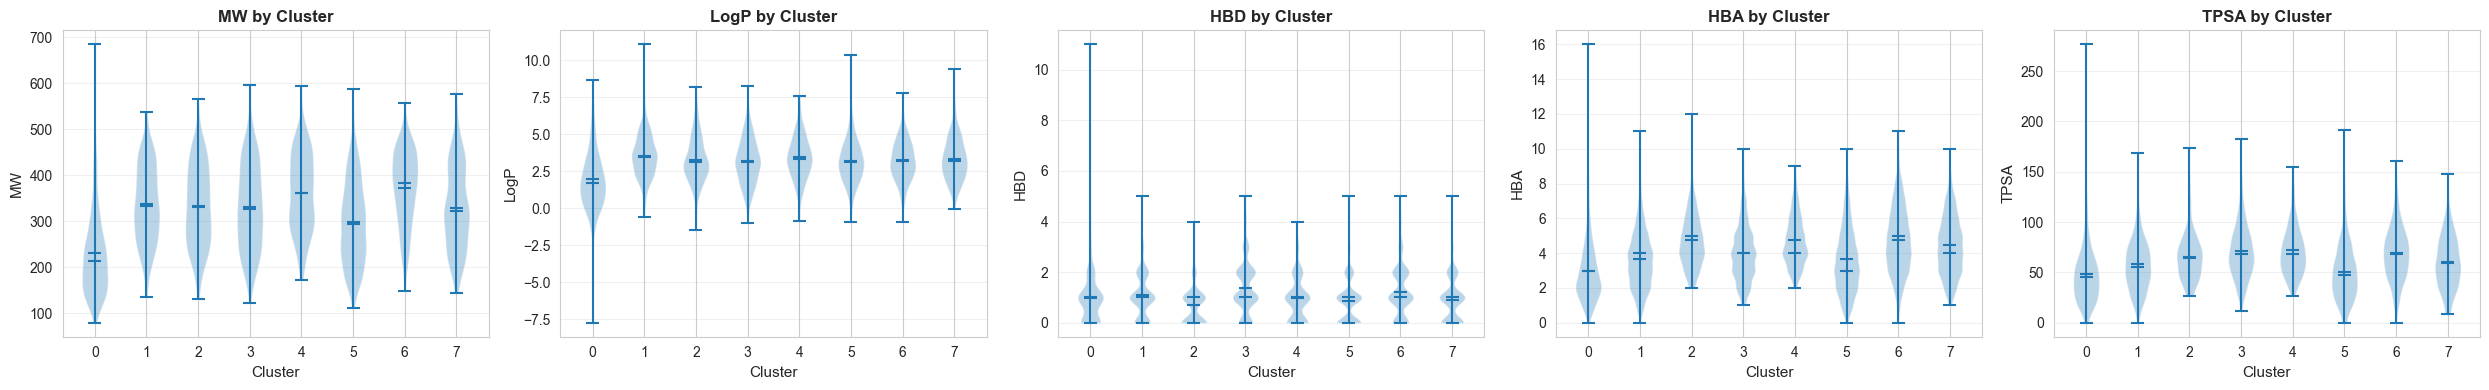

In [16]:
def plot_descriptor_distributions(df, cluster_col='cluster_struct', 
                                 descriptors=['MW', 'LogP', 'HBD', 'HBA', 'TPSA']):
    """
    Plot distributions of molecular descriptors by cluster.
    """
    # Filter out noise cluster
    df_clustered = df[df[cluster_col] >= 0].copy()
    
    n_desc = len(descriptors)
    fig, axes = plt.subplots(1, n_desc, figsize=(5*n_desc, 4))
    
    if n_desc == 1:
        axes = [axes]
    
    for i, desc in enumerate(descriptors):
        ax = axes[i]
        
        # Violin plot
        unique_clusters = sorted(df_clustered[cluster_col].unique())
        data_by_cluster = [df_clustered[df_clustered[cluster_col] == c][desc].values 
                          for c in unique_clusters]
        
        parts = ax.violinplot(data_by_cluster, positions=unique_clusters,
                             showmeans=True, showmedians=True)
        
        ax.set_xlabel('Cluster', fontsize=11)
        ax.set_ylabel(desc, fontsize=11)
        ax.set_title(f'{desc} by Cluster', fontweight='bold')
        ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    plt.show()

print("Creating descriptor distribution plots...")
plot_descriptor_distributions(
    df,
    cluster_col='cluster_struct',
    descriptors=['MW', 'LogP', 'HBD', 'HBA', 'TPSA']
)

## 17. Interpretation & Summary

Generate insights about structure-spectra relationships

In [ ]:
def generate_interpretation_report(df, cluster_labels, df_ari, df_nmi):
    """
    Generate text-based interpretation of results.
    """
    report = []
    report.append("="*80)
    report.append("SIMILARITY ANALYSIS - INTERPRETATION REPORT")
    report.append("="*80)
    
    # Dataset summary
    report.append("\n1. DATASET SUMMARY")
    report.append("-" * 40)
    report.append(f"Total molecules analyzed: {len(df):,}")
    report.append(f"Random seed: {RANDOM_SEED}")
    
    # Clustering summary
    report.append("\n2. CLUSTERING SUMMARY")
    report.append("-" * 40)
    
    for modality, labels in cluster_labels.items():
        n_clusters = len([c for c in set(labels) if c >= 0])
        n_noise = (labels == -1).sum()
        report.append(f"\n{modality.upper()}:")
        report.append(f"  Clusters: {n_clusters}")
        if n_noise > 0:
            report.append(f"  Noise points: {n_noise} ({n_noise/len(labels)*100:.1f}%)")
    
    # Cross-modal agreement
    report.append("\n3. CROSS-MODAL AGREEMENT")
    report.append("-" * 40)
    report.append("\nTop 5 modality pairs with highest agreement (ARI):")
    
    # Get off-diagonal ARI values
    ari_values = []
    for i in range(len(df_ari)):
        for j in range(i+1, len(df_ari)):
            ari_values.append((
                df_ari.index[i],
                df_ari.columns[j],
                df_ari.iloc[i, j]
            ))
    
    ari_values_sorted = sorted(ari_values, key=lambda x: x[2], reverse=True)
    
    for mod1, mod2, ari in ari_values_sorted[:5]:
        report.append(f"  {mod1} ↔ {mod2}: {ari:.3f}")
    
    # Key findings
    report.append("\n4. KEY FINDINGS")
    report.append("-" * 40)
    
    # Find best agreement
    best_pair = ari_values_sorted[0]
    report.append(f"\n• Best cross-modal agreement: {best_pair[0]} ↔ {best_pair[1]} (ARI={best_pair[2]:.3f})")
    
    if best_pair[2] > 0.5:
        report.append("  → Strong correspondence suggests these modalities capture similar chemical features")
    elif best_pair[2] > 0.3:
        report.append("  → Moderate correspondence suggests partial overlap in chemical information")
    else:
        report.append("  → Weak correspondence suggests modalities capture different chemical features")
    
    # Structure vs all spectra
    struct_agreements = []
    for i, mod in enumerate(df_ari.columns):
        if mod != 'Structure':
            struct_agreements.append((mod, df_ari.loc['Structure', mod]))
    
    struct_agreements_sorted = sorted(struct_agreements, key=lambda x: x[1], reverse=True)
    
    report.append("\n• Structure-Spectra correspondence:")
    for mod, ari in struct_agreements_sorted:
        report.append(f"  Structure ↔ {mod}: {ari:.3f}")
    
    # Interpretation
    report.append("\n5. INTERPRETATION")
    report.append("-" * 40)
    
    avg_agreement = np.mean([x[2] for x in ari_values])
    
    if avg_agreement > 0.4:
        report.append("\n✓ Overall high cross-modal agreement suggests:")
        report.append("  - Dataset contains natural chemical groupings")
        report.append("  - Structure correlates well with spectroscopic properties")
        report.append("  - Clusters likely represent distinct chemical classes")
    elif avg_agreement > 0.2:
        report.append("\n⚠ Moderate cross-modal agreement suggests:")
        report.append("  - Some modalities capture different aspects of chemistry")
        report.append("  - Structural diversity may not fully explain spectral diversity")
        report.append("  - Consider: isomers, conformers, or measurement noise")
    else:
        report.append("\n⚠ Low cross-modal agreement suggests:")
        report.append("  - Modalities capture largely independent information")
        report.append("  - High structural diversity with overlapping spectra")
        report.append("  - Possible data quality issues or very heterogeneous dataset")
    
    # Print report
    report_text = "\n".join(report)
    print(report_text)

generate_interpretation_report(df, cluster_labels, df_ari, df_nmi)

SIMILARITY ANALYSIS - INTERPRETATION REPORT

1. DATASET SUMMARY
----------------------------------------
Total molecules analyzed: 4,999
Random seed: 42

2. CLUSTERING SUMMARY
----------------------------------------

STRUCTURE:
  Clusters: 0
  Noise points: 4999 (100.0%)

NMR_H:
  Clusters: 86
  Noise points: 2573 (51.5%)

NMR_C:
  Clusters: 127
  Noise points: 1451 (29.0%)

IR:
  Clusters: 7
  Noise points: 4487 (89.8%)

MSMS_POS:
  Clusters: 0
  Noise points: 4999 (100.0%)

MSMS_NEG:
  Clusters: 0
  Noise points: 4999 (100.0%)

3. CROSS-MODAL AGREEMENT
----------------------------------------

Top 5 modality pairs with highest agreement (ARI):
  1H NMR ↔ 13C NMR: 0.013
  1H NMR ↔ IR: 0.001
  13C NMR ↔ IR: 0.001
  Structure ↔ 1H NMR: 0.000
  Structure ↔ 13C NMR: 0.000

4. KEY FINDINGS
----------------------------------------

• Best cross-modal agreement: 1H NMR ↔ 13C NMR (ARI=0.013)
  → Weak correspondence suggests modalities capture different chemical features

• Structure-Spectra 

## 18. Analysis Summary

Final statistics and completion message

In [ ]:
print(f"{'='*80}")
print(f"ANALYSIS COMPLETE!")
print(f"{'='*80}")
print(f"\nDataset: {len(df):,} molecules analyzed")
print(f"\nClusters discovered:")
for modality, labels in cluster_labels.items():
    n_clusters = len([c for c in set(labels) if c >= 0])
    print(f"  {modality}: {n_clusters} clusters")

print(f"\n✓ All visualizations displayed in notebook outputs above")
print(f"\nNote: Results are displayed in-notebook only (no files saved)")
print(f"      If you need to export results, you can access:")
print(f"      - df (full dataframe with cluster assignments)")
print(f"      - embeddings (dict with UMAP/PCA for each modality)")
print(f"      - cluster_labels (dict with labels for each modality)")
print(f"      - df_ari, df_nmi (agreement matrices)")

ANALYSIS COMPLETE!

Dataset: 4,999 molecules analyzed

Clusters discovered:
  structure: 0 clusters
  nmr_h: 86 clusters
  nmr_c: 127 clusters
  ir: 7 clusters
  msms_pos: 0 clusters
  msms_neg: 0 clusters

✓ All visualizations displayed in notebook outputs above

Note: Results are displayed in-notebook only (no files saved)
      If you need to export results, you can access:
      - df (full dataframe with cluster assignments)
      - embeddings (dict with UMAP/PCA for each modality)
      - cluster_labels (dict with labels for each modality)
      - df_ari, df_nmi (agreement matrices)


## Summary

This notebook provides a complete pipeline for analyzing structure-spectra similarity patterns:

**What we did:**
1. ✓ Efficiently sampled from large dataset (~59M molecules)
2. ✓ Computed structural representations (Morgan fingerprints + descriptors)
3. ✓ Vectorized all spectral modalities (NMR, IR, MS/MS)
4. ✓ Applied dimensionality reduction (UMAP, PCA)
5. ✓ Performed unsupervised clustering (HDBSCAN/KMeans)
6. ✓ Visualized each modality and cross-modal relationships
7. ✓ Quantified agreement between modalities (ARI, NMI)
8. ✓ Generated interpretation and insights

**Key insights obtained:**
- Which modalities show the clearest clustering
- How well structural similarity predicts spectral similarity
- Natural groupings in the dataset
- Chemical properties that distinguish clusters

**All results displayed in notebook outputs** - no files saved to disk.

**Next steps:**
- Adjust sampling size and clustering parameters as needed
- Investigate specific clusters of interest
- Export data manually if needed (e.g., `df.to_csv(...)`, `np.save(...)`)
- Use cluster assignments for supervised learning tasks
- Explore outliers and noise points

**Available variables for export:**
- `df` - Full dataframe with molecules and cluster assignments
- `fps_morgan` - Morgan fingerprint matrix
- `nmr_h_vectors`, `nmr_c_vectors`, `ir_vectors`, `msms_pos_vectors`, `msms_neg_vectors` - Spectral vectors
- `embeddings` - Dict with UMAP/PCA embeddings for each modality
- `cluster_labels` - Dict with cluster labels for each modality
- `df_ari`, `df_nmi` - Cross-modal agreement matrices